# Wine Quality ML Project — Red and White Wines

## The question

Can chemical measurements predict whether a **red or white wine** has **Low**, **Medium**, or **High** quality?

## The story

1. Combine the red and white UCI wine datasets.
2. Show why high accuracy can hide weak rare-class predictions.
3. Compare Random Forest, SMOTE, tuned XGBoost, and cost-sensitive XGBoost.
4. Use regression to predict the original numerical quality score.
5. Predict whether one new wine is **Bad**, **Normal**, or **Good**.

This notebook keeps only the code, explanations, and results needed to understand the project clearly.

## 1. Setup

If a library is missing, remove the `#` and run the installation line once.

In [1]:
# %pip install xgboost imbalanced-learn seaborn

In [2]:
import warnings
from pathlib import Path
from urllib.request import urlopen
from zipfile import ZipFile
from io import BytesIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier, XGBRegressor

warnings.filterwarnings("ignore")
SEED = 42
CLASS_NAMES = ["Low", "Medium", "High"]
sns.set_theme(style="whitegrid")

print("Setup complete.")

Setup complete.


## 2. Data and target

The UCI Wine Quality dataset contains red and white Portuguese *Vinho Verde* wines. The inputs are 11 chemical measurements, while `quality` is a sensory score.

The original score is converted using simple bins:

- **Low:** 3–4
- **Medium:** 5–6
- **High:** 7–9

`wine_type` is added as a useful feature:

- `0` = red wine
- `1` = white wine

Source: [UCI Wine Quality dataset](https://archive.ics.uci.edu/dataset/186/wine+quality), Cortez et al. (2009), DOI: 10.24432/C56S3T.

In [3]:
RED_PATHS = [Path("winequality-red.csv"), Path("upload/winequality-red.csv")]
WHITE_PATHS = [Path("winequality-white.csv"), Path("upload/winequality-white.csv")]
UCI_URL = "https://archive.ics.uci.edu/static/public/186/wine+quality.zip"

red_path = next((path for path in RED_PATHS if path.exists()), None)
white_path = next((path for path in WHITE_PATHS if path.exists()), None)

if red_path is not None and white_path is not None:
    red_wines = pd.read_csv(red_path, sep=";")
    white_wines = pd.read_csv(white_path, sep=";")
else:
    with urlopen(UCI_URL) as response:
        zip_data = BytesIO(response.read())
    with ZipFile(zip_data) as archive:
        with archive.open("winequality-red.csv") as file:
            red_wines = pd.read_csv(file, sep=";")
        with archive.open("winequality-white.csv") as file:
            white_wines = pd.read_csv(file, sep=";")

red_wines["wine_type"] = 0
white_wines["wine_type"] = 1

df = pd.concat([red_wines, white_wines], ignore_index=True)
raw_row_count = len(df)
duplicate_count = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)

df["quality_class"] = pd.cut(
    df["quality"],
    bins=[2, 4, 6, 9],
    labels=[0, 1, 2],
    include_lowest=True,
).astype(int)

print(f"Red wines:   {len(red_wines):,}")
print(f"White wines: {len(white_wines):,}")
print(f"Raw total:   {raw_row_count:,}")
print(f"Exact duplicate rows removed: {duplicate_count:,}")
print(f"Rows used for modelling: {len(df):,}")
print(f"Missing values: {df.isna().sum().sum()}")
display(df.head())

Red wines:   1,599
White wines: 4,898
Raw total:   6,497
Exact duplicate rows removed: 1,177
Rows used for modelling: 5,320
Missing values: 0


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type,quality_class
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0,1
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,0,1


,Count,Percentage
Low,236,4.44
Medium,4075,76.60
High,1009,18.97


quality_class,Low,Medium,High
wine_type,,,
Red,63,1112,184
White,173,2963,825


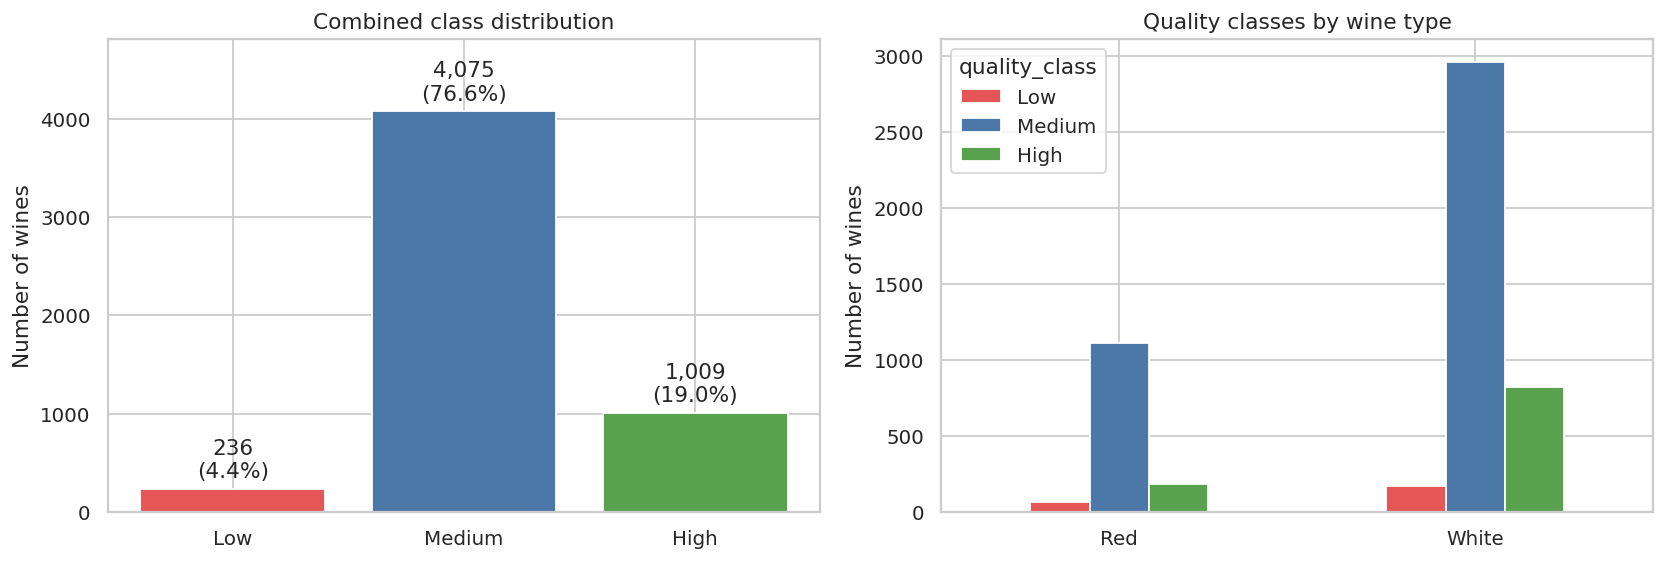

In [4]:
class_summary = df["quality_class"].value_counts().sort_index().to_frame("Count")
class_summary.index = CLASS_NAMES
class_summary["Percentage"] = 100 * class_summary["Count"] / len(df)
display(class_summary.round(2))

class_by_type = pd.crosstab(
    df["wine_type"].map({0: "Red", 1: "White"}),
    df["quality_class"].map({0: "Low", 1: "Medium", 2: "High"}),
).reindex(index=["Red", "White"], columns=CLASS_NAMES)
display(class_by_type)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colors = ["#E45756", "#4C78A8", "#59A14F"]

bars = axes[0].bar(class_summary.index, class_summary["Count"], color=colors)
axes[0].bar_label(
    bars,
    labels=[f"{count:,}\n({percentage:.1f}%)" for count, percentage in zip(
        class_summary["Count"], class_summary["Percentage"]
    )],
    padding=4,
)
axes[0].set_title("Combined class distribution")
axes[0].set_ylabel("Number of wines")
axes[0].set_ylim(0, class_summary["Count"].max() * 1.18)

class_by_type.plot(kind="bar", color=colors, ax=axes[1])
axes[1].set_title("Quality classes by wine type")
axes[1].set_xlabel("")
axes[1].set_ylabel("Number of wines")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### Key problem

Only **236 of 5,320 unique rows** are Low. A model can obtain high accuracy by predicting Medium most of the time. Therefore, our main measurements are:

- **Macro F1:** treats all three classes equally.
- **Low recall:** percentage of real Low wines found.
- **High recall:** percentage of real High wines found.

Adding the white wines gives us much more data, especially more High wines. Exact duplicate rows are removed before splitting the data. However, the Low class remains only about 4% of the modelling dataset, so imbalance is still a real problem.

## 3. Train/test split

`stratify=y` keeps similar class percentages in train and test. It does **not** balance the data.

In [5]:
X = df.drop(columns=["quality", "quality_class"])
y = df["quality_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")
print(f"Low wines in the test set: {(y_test == 0).sum()}")
print(f"Red wines in the test set: {(X_test['wine_type'] == 0).sum()}")
print(f"White wines in the test set: {(X_test['wine_type'] == 1).sum()}")

Training rows: 4256
Test rows: 1064
Low wines in the test set: 47
Red wines in the test set: 278
White wines in the test set: 786


## 4. Five classification models

We keep four models because each one answers a useful question:

| Model | Purpose |
|---|---|
| Basic Random Forest | Starting point, no balancing |
| Weighted Random Forest | Makes rare-class mistakes more costly |
| Random Search XGBoost + SMOTE | Broad parameter search after balancing |
| Grid Search XGBoost + SMOTE | Smaller search around the Random Search winner |
| Cost-sensitive XGBoost | Uses row weights instead of synthetic data |

In [6]:
# MODEL 1 — Basic Random Forest: no balancing
rf_basic = RandomForestClassifier(random_state=SEED, n_jobs=1)
rf_basic.fit(X_train, y_train)
y_pred_train_rf_basic = rf_basic.predict(X_train)
y_pred_rf_basic = rf_basic.predict(X_test)

print("MODEL 1 — BASIC RANDOM FOREST")
print(f"Accuracy (Train): {accuracy_score(y_train, y_pred_train_rf_basic):.2%}")
print(f"Accuracy (Test):  {accuracy_score(y_test, y_pred_rf_basic):.2%}")
print(f"Balanced Accuracy (Test): {balanced_accuracy_score(y_test, y_pred_rf_basic):.2%}")
print(f"Macro F1 (Test): {f1_score(y_test, y_pred_rf_basic, average='macro'):.3f}")
print()
print("Classification Report (Test):")
print(classification_report(
    y_test,
    y_pred_rf_basic,
    labels=[0, 1, 2],
    target_names=CLASS_NAMES,
    zero_division=0,
))

# MODEL 2 — Weighted Random Forest: changes the cost of mistakes
rf_weighted = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=1,
)
rf_weighted.fit(X_train, y_train)
y_pred_train_rf_weighted = rf_weighted.predict(X_train)
y_pred_rf_weighted = rf_weighted.predict(X_test)

print("MODEL 2 — WEIGHTED RANDOM FOREST")
print(f"Accuracy (Train): {accuracy_score(y_train, y_pred_train_rf_weighted):.2%}")
print(f"Accuracy (Test):  {accuracy_score(y_test, y_pred_rf_weighted):.2%}")
print(f"Balanced Accuracy (Test): {balanced_accuracy_score(y_test, y_pred_rf_weighted):.2%}")
print(f"Macro F1 (Test): {f1_score(y_test, y_pred_rf_weighted, average='macro'):.3f}")
print()
print("Classification Report (Test):")
print(classification_report(
    y_test,
    y_pred_rf_weighted,
    labels=[0, 1, 2],
    target_names=CLASS_NAMES,
    zero_division=0,
))

MODEL 1 — BASIC RANDOM FOREST
Accuracy (Train): 100.00%
Accuracy (Test):  79.42%
Balanced Accuracy (Test): 44.04%
Macro F1 (Test): 0.457

Classification Report (Test):
              precision    recall  f1-score   support

         Low       0.20      0.02      0.04        47
      Medium       0.81      0.95      0.88       815
        High       0.65      0.35      0.46       202

    accuracy                           0.79      1064
   macro avg       0.55      0.44      0.46      1064
weighted avg       0.76      0.79      0.76      1064

MODEL 2 — WEIGHTED RANDOM FOREST
Accuracy (Train): 100.00%
Accuracy (Test):  79.98%
Balanced Accuracy (Test): 43.79%
Macro F1 (Test): 0.456

Classification Report (Test):
              precision    recall  f1-score   support

         Low       0.25      0.02      0.04        47
      Medium       0.81      0.96      0.88       815
        High       0.70      0.33      0.45       202

    accuracy                           0.80      1064
   macro

### XGBoost + SMOTE — three separate steps

The process is separated so it is easier to follow:

1. Use SMOTE to balance only the training data.
2. Use Randomized Search for a broad search.
3. Use Grid Search for a smaller search around the Randomized Search winner.

The test data is never changed by SMOTE.

#### Step 1 — Balance the training data with SMOTE

SMOTE creates artificial examples of the rare classes. `fit_resample()` returns a new balanced training dataset.

In [7]:
smote = SMOTE(
    random_state=SEED,
    k_neighbors=3,
)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

before_smote = y_train.value_counts().sort_index()
after_smote = y_train_smote.value_counts().sort_index()

smote_counts = pd.DataFrame({
    "Before SMOTE": before_smote,
    "After SMOTE": after_smote,
})
smote_counts.index = CLASS_NAMES
display(smote_counts)

,Before SMOTE,After SMOTE
Low,189,3260
Medium,3260,3260
High,807,3260


#### Step 2 — Randomized Search

Randomized Search tries a sample of different parameter combinations. It searches a wide area relatively quickly.

In [8]:
xgb_random_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=SEED,
    n_jobs=1,
)

xgb_random_parameters = {
    "n_estimators": [100, 200, 350, 500],
    "learning_rate": [0.02, 0.05, 0.10, 0.20],
    "max_depth": [2, 3, 4, 5, 6],
    "min_child_weight": [1, 3, 5, 8],
    "subsample": [0.70, 0.85, 1.00],
    "colsample_bytree": [0.70, 0.85, 1.00],
    "gamma": [0.0, 0.1, 0.3, 0.5],
    "reg_lambda": [1, 3, 5, 10],
}

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_random_model,
    param_distributions=xgb_random_parameters,
    n_iter=14,
    scoring="f1_macro",
    cv=3,
    random_state=SEED,
    n_jobs=1,
)

xgb_random_search.fit(X_train_smote, y_train_smote)

xgb_random_best = xgb_random_search.best_estimator_
y_pred_train_xgb_random = xgb_random_best.predict(X_train)
y_pred_test_xgb_random = xgb_random_best.predict(X_test)

print("RANDOMIZED SEARCH RESULT")
print("Best settings:")
display(pd.Series(xgb_random_search.best_params_, name="Value").to_frame())
print(f"Best average CV macro F1: {xgb_random_search.best_score_:.3f}")
print(f"Accuracy (Train): {accuracy_score(y_train, y_pred_train_xgb_random):.2%}")
print(f"Accuracy (Test):  {accuracy_score(y_test, y_pred_test_xgb_random):.2%}")
print(f"Balanced Accuracy (Test): {balanced_accuracy_score(y_test, y_pred_test_xgb_random):.2%}")
print(f"Macro F1 (Test): {f1_score(y_test, y_pred_test_xgb_random, average='macro'):.3f}")
print()
print("Classification Report (Test):")
print(classification_report(
    y_test,
    y_pred_test_xgb_random,
    labels=[0, 1, 2],
    target_names=CLASS_NAMES,
    zero_division=0,
))

RANDOMIZED SEARCH RESULT
Best settings:
Best average CV macro F1: 0.871
Accuracy (Train): 98.45%
Accuracy (Test):  76.22%
Balanced Accuracy (Test): 52.39%
Macro F1 (Test): 0.534

Classification Report (Test):
              precision    recall  f1-score   support

         Low       0.28      0.21      0.24        47
      Medium       0.84      0.86      0.85       815
        High       0.53      0.50      0.51       202

    accuracy                           0.76      1064
   macro avg       0.55      0.52      0.53      1064
weighted avg       0.75      0.76      0.76      1064



,Value
subsample,0.7
reg_lambda,5.0
n_estimators,500.0
min_child_weight,5.0
max_depth,5.0
learning_rate,0.1
gamma,0.1
colsample_bytree,1.0


#### Step 3 — Grid Search

Grid Search starts from the Randomized Search winner. It tests every combination in a small area around its best number of trees, tree depth, and minimum child weight.

Random Search and Grid Search remain separate, so we can compare whether the extra tuning actually improves the unseen test data.

In [9]:
best_n_estimators = xgb_random_search.best_params_["n_estimators"]
best_depth = xgb_random_search.best_params_["max_depth"]
best_child_weight = xgb_random_search.best_params_["min_child_weight"]

xgb_grid_parameters = {
    "n_estimators": sorted(set([
        max(100, best_n_estimators - 100),
        best_n_estimators,
        min(700, best_n_estimators + 100),
    ])),
    "max_depth": sorted(set([
        max(2, best_depth - 1),
        best_depth,
        min(7, best_depth + 1),
    ])),
    "min_child_weight": sorted(set([
        best_child_weight,
        min(10, best_child_weight + 2),
    ])),
}

print("Small Grid Search area:")
display(pd.Series(xgb_grid_parameters, name="Values").to_frame())

xgb_grid_search = GridSearchCV(
    estimator=xgb_random_search.best_estimator_,
    param_grid=xgb_grid_parameters,
    scoring="f1_macro",
    cv=3,
    n_jobs=1,
)

xgb_grid_search.fit(X_train_smote, y_train_smote)

xgb_smote = xgb_grid_search.best_estimator_
y_pred_train_xgb_smote = xgb_smote.predict(X_train)
y_pred_xgb_smote = xgb_smote.predict(X_test)

print("MODEL 3 — GRID-SEARCHED XGBOOST + SMOTE")
print("Best settings:")
display(pd.Series(xgb_grid_search.best_params_, name="Value").to_frame())
print(f"Best average CV macro F1: {xgb_grid_search.best_score_:.3f}")
print(f"Accuracy (Train): {accuracy_score(y_train, y_pred_train_xgb_smote):.2%}")
print(f"Accuracy (Test):  {accuracy_score(y_test, y_pred_xgb_smote):.2%}")
print(f"Balanced Accuracy (Test): {balanced_accuracy_score(y_test, y_pred_xgb_smote):.2%}")
print(f"Macro F1 (Test): {f1_score(y_test, y_pred_xgb_smote, average='macro'):.3f}")
print()
print("Classification Report (Test):")
print(classification_report(
    y_test,
    y_pred_xgb_smote,
    labels=[0, 1, 2],
    target_names=CLASS_NAMES,
    zero_division=0,
))

Small Grid Search area:
MODEL 3 — GRID-SEARCHED XGBOOST + SMOTE
Best settings:
Best average CV macro F1: 0.875
Accuracy (Train): 99.91%
Accuracy (Test):  75.47%
Balanced Accuracy (Test): 52.61%
Macro F1 (Test): 0.534

Classification Report (Test):
              precision    recall  f1-score   support

         Low       0.30      0.23      0.26        47
      Medium       0.84      0.85      0.84       815
        High       0.50      0.50      0.50       202

    accuracy                           0.75      1064
   macro avg       0.55      0.53      0.53      1064
weighted avg       0.75      0.75      0.75      1064



,Values
n_estimators,"[400, 500, 600]"
max_depth,"[4, 5, 6]"
min_child_weight,"[5, 7]"


,Value
max_depth,6
min_child_weight,7
n_estimators,600


> Beginner note: this notebook applies SMOTE once to the training data for readability. In a more advanced project, SMOTE is placed inside a pipeline so it is repeated separately inside every cross-validation fold. The final test set here remains untouched.

### Cost-sensitive XGBoost

For three classes, we use `sample_weight` instead of `scale_pos_weight`.

The weight tells XGBoost that missing a rare Low or High wine is more costly than missing a Medium wine. Unlike SMOTE, this method does not create synthetic rows.

We use a short Randomized Search to tune the model by macro F1.

In [10]:
training_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train,
)

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=y_train,
)

weight_table = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Training weight": class_weight_values,
})
display(weight_table.round(2))

xgb_cost_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=SEED,
    n_jobs=1,
)

cost_search_space = {
    "n_estimators": [100, 200, 350, 500],
    "learning_rate": [0.02, 0.05, 0.10, 0.20],
    "max_depth": [2, 3, 4, 5, 6],
    "min_child_weight": [1, 3, 5, 8],
    "subsample": [0.70, 0.85, 1.00],
    "colsample_bytree": [0.70, 0.85, 1.00],
    "gamma": [0.0, 0.1, 0.3, 0.5],
    "reg_lambda": [1, 3, 5, 10],
}

xgb_cost_search = RandomizedSearchCV(
    estimator=xgb_cost_model,
    param_distributions=cost_search_space,
    n_iter=16,
    scoring="f1_macro",
    cv=3,
    random_state=SEED,
    n_jobs=1,
)

xgb_cost_search.fit(
    X_train,
    y_train,
    sample_weight=training_weights,
)

xgb_cost = xgb_cost_search.best_estimator_
y_pred_train_xgb_cost = xgb_cost.predict(X_train)
y_pred_xgb_cost = xgb_cost.predict(X_test)

print(f"Best cross-validation macro F1: {xgb_cost_search.best_score_:.3f}")
print("Best settings:")
display(pd.Series(xgb_cost_search.best_params_, name="Value").to_frame())
print()
print("MODEL 4 — COST-SENSITIVE XGBOOST")
print(f"Accuracy (Train): {accuracy_score(y_train, y_pred_train_xgb_cost):.2%}")
print(f"Accuracy (Test):  {accuracy_score(y_test, y_pred_xgb_cost):.2%}")
print(f"Balanced Accuracy (Test): {balanced_accuracy_score(y_test, y_pred_xgb_cost):.2%}")
print(f"Macro F1 (Test): {f1_score(y_test, y_pred_xgb_cost, average='macro'):.3f}")
print()
print("Classification Report (Test):")
print(classification_report(
    y_test,
    y_pred_xgb_cost,
    labels=[0, 1, 2],
    target_names=CLASS_NAMES,
    zero_division=0,
))

Best cross-validation macro F1: 0.632
Best settings:

MODEL 4 — COST-SENSITIVE XGBOOST
Accuracy (Train): 72.58%
Accuracy (Test):  65.13%
Balanced Accuracy (Test): 67.88%
Macro F1 (Test): 0.546

Classification Report (Test):
              precision    recall  f1-score   support

         Low       0.26      0.64      0.37        47
      Medium       0.90      0.62      0.74       815
        High       0.40      0.78      0.53       202

    accuracy                           0.65      1064
   macro avg       0.52      0.68      0.55      1064
weighted avg       0.78      0.65      0.68      1064



,Class,Training weight
0,Low,7.51
1,Medium,0.44
2,High,1.76


,Value
subsample,1.00
reg_lambda,3.00
n_estimators,100.00
min_child_weight,8.00
max_depth,5.00
learning_rate,0.05
gamma,0.00
colsample_bytree,0.70


## 5. Final classification results

This is the most important table and graph in the project.

,Accuracy,Macro F1,Balanced accuracy,Low recall,High recall
Model,,,,,
Basic RF,0.794,0.457,0.440,0.021,0.351
Weighted RF,0.800,0.456,0.438,0.021,0.332
Random Search XGB + SMOTE,0.762,0.534,0.524,0.213,0.500
Grid Search XGB + SMOTE,0.755,0.534,0.526,0.234,0.495
Cost-sensitive XGBoost,0.651,0.546,0.679,0.638,0.777


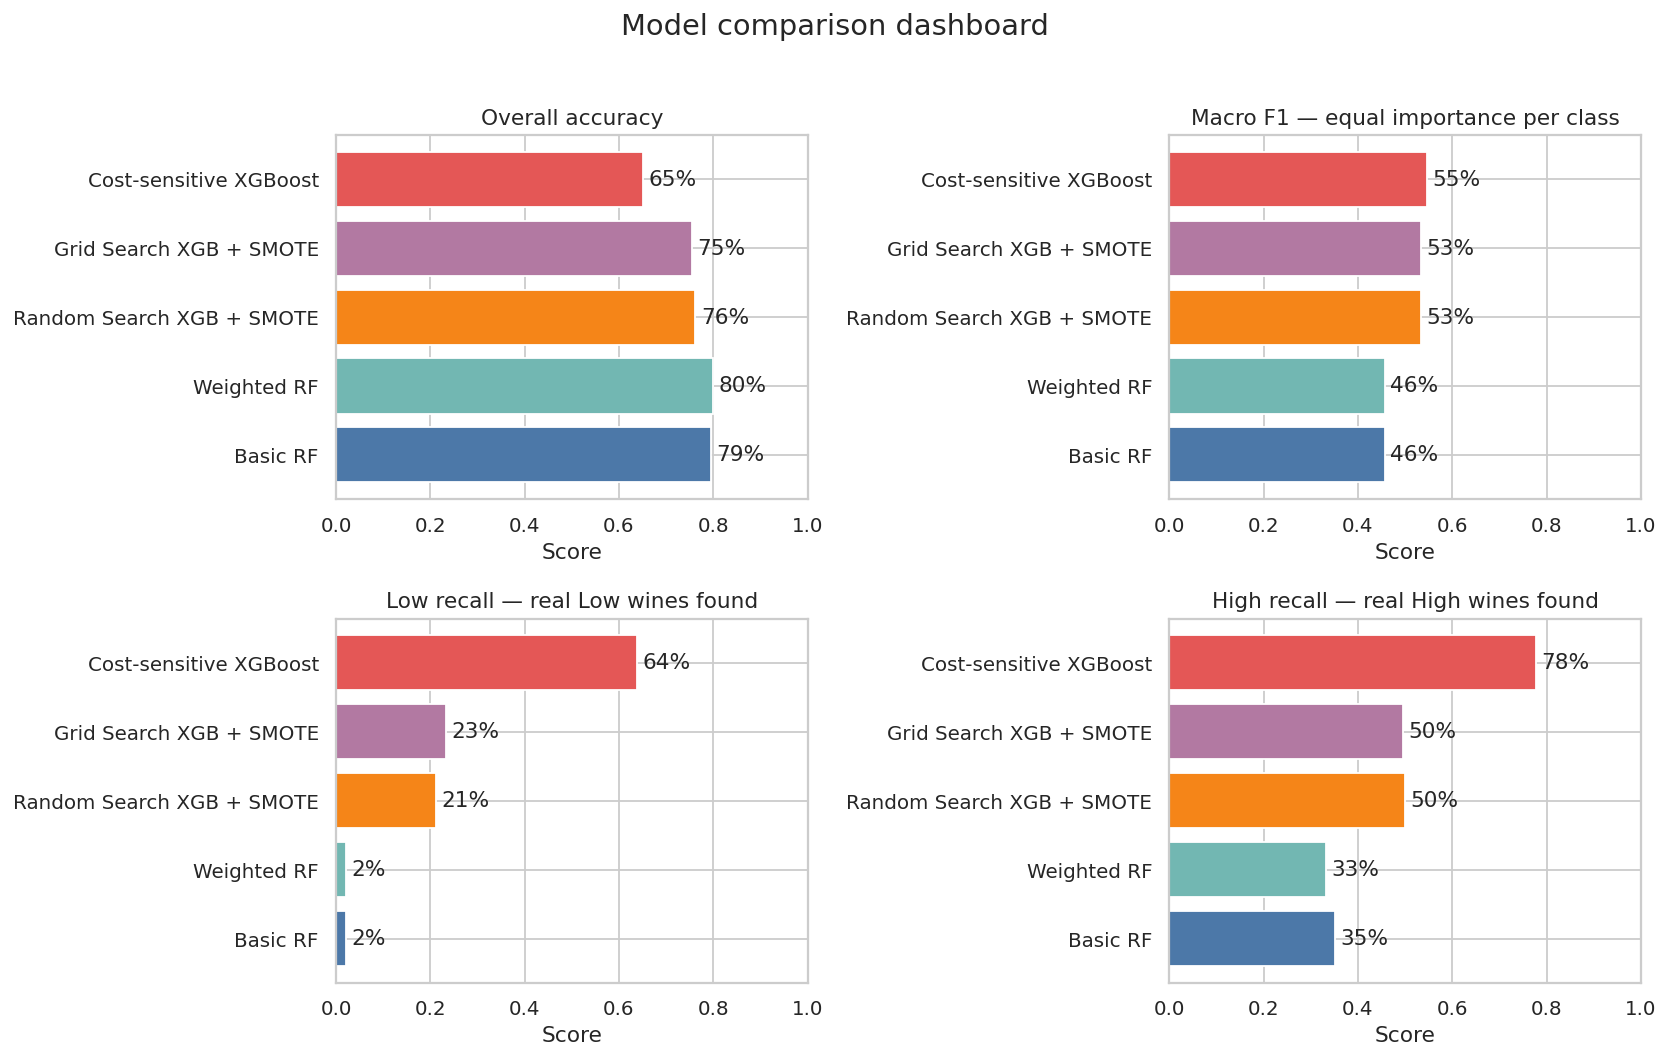

In [11]:
classification_predictions = {
    "Basic RF": y_pred_rf_basic,
    "Weighted RF": y_pred_rf_weighted,
    "Random Search XGB + SMOTE": y_pred_test_xgb_random,
    "Grid Search XGB + SMOTE": y_pred_xgb_smote,
    "Cost-sensitive XGBoost": y_pred_xgb_cost,
}

result_rows = []

for model_name, prediction in classification_predictions.items():
    result_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, prediction),
        "Macro F1": f1_score(y_test, prediction, average="macro"),
        "Balanced accuracy": balanced_accuracy_score(y_test, prediction),
        "Low recall": recall_score(
            y_test, prediction, labels=[0], average="macro", zero_division=0
        ),
        "High recall": recall_score(
            y_test, prediction, labels=[2], average="macro", zero_division=0
        ),
    })

classification_results = pd.DataFrame(result_rows).set_index("Model")
display(classification_results.round(3))

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
dashboard_metrics = [
    ("Accuracy", "Overall accuracy"),
    ("Macro F1", "Macro F1 — equal importance per class"),
    ("Low recall", "Low recall — real Low wines found"),
    ("High recall", "High recall — real High wines found"),
]
dashboard_colors = ["#4C78A8", "#72B7B2", "#F58518", "#B279A2", "#E45756"]

for ax, (metric, title) in zip(axes.flat, dashboard_metrics):
    values = classification_results[metric]
    bars = ax.barh(values.index, values.values, color=dashboard_colors)
    ax.set_xlim(0, 1)
    ax.set_title(title)
    ax.set_xlabel("Score")
    ax.bar_label(bars, labels=[f"{value:.0%}" for value in values], padding=3)

plt.suptitle("Model comparison dashboard", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### How to read the dashboard

- **Accuracy** can look strong because Medium is the largest class.
- **Macro F1** is better for choosing the most balanced model because each class has equal importance.
- **Low recall** shows whether the model finds the rare poor wines.
- **High recall** shows whether the model finds the good wines.
- Grid Search does not automatically win. Extra tuning can improve cross-validation without improving the final test set.

There is no universally best model. The best choice depends on whether overall balance or finding rare wines is more important.

### Results for red and white wines separately

The combined model uses both types of wine. This table checks whether its performance is similar for red and white wines instead of hiding one type inside the overall result.

In [12]:
best_overall_model_name = classification_results["Macro F1"].idxmax()
best_overall_prediction = classification_predictions[best_overall_model_name]

type_result_rows = []
for wine_type_value, wine_type_name in [(0, "Red"), (1, "White")]:
    mask = X_test["wine_type"].to_numpy() == wine_type_value
    type_result_rows.append({
        "Wine type": wine_type_name,
        "Test rows": int(mask.sum()),
        "Accuracy": accuracy_score(y_test[mask], best_overall_prediction[mask]),
        "Macro F1": f1_score(
            y_test[mask], best_overall_prediction[mask], average="macro", zero_division=0
        ),
        "Low recall": recall_score(
            y_test[mask], best_overall_prediction[mask], labels=[0],
            average="macro", zero_division=0
        ),
        "High recall": recall_score(
            y_test[mask], best_overall_prediction[mask], labels=[2],
            average="macro", zero_division=0
        ),
    })

results_by_wine_type = pd.DataFrame(type_result_rows).set_index("Wine type")
print(f"Model checked: {best_overall_model_name}")
display(results_by_wine_type.round(3))

Model checked: Cost-sensitive XGBoost


,Test rows,Accuracy,Macro F1,Low recall,High recall
Wine type,,,,,
Red,278,0.687,0.540,0.636,0.711
White,786,0.639,0.549,0.639,0.796


## 6. Inspect the two useful XGBoost models

The classification reports show precision and recall. The confusion matrices show exactly where the predictions went.

RANDOM SEARCH XGBOOST + SMOTE
              precision    recall  f1-score   support

         Low       0.28      0.21      0.24        47
      Medium       0.84      0.86      0.85       815
        High       0.53      0.50      0.51       202

    accuracy                           0.76      1064
   macro avg       0.55      0.52      0.53      1064
weighted avg       0.75      0.76      0.76      1064

COST-SENSITIVE XGBOOST
              precision    recall  f1-score   support

         Low       0.26      0.64      0.37        47
      Medium       0.90      0.62      0.74       815
        High       0.40      0.78      0.53       202

    accuracy                           0.65      1064
   macro avg       0.52      0.68      0.55      1064
weighted avg       0.78      0.65      0.68      1064



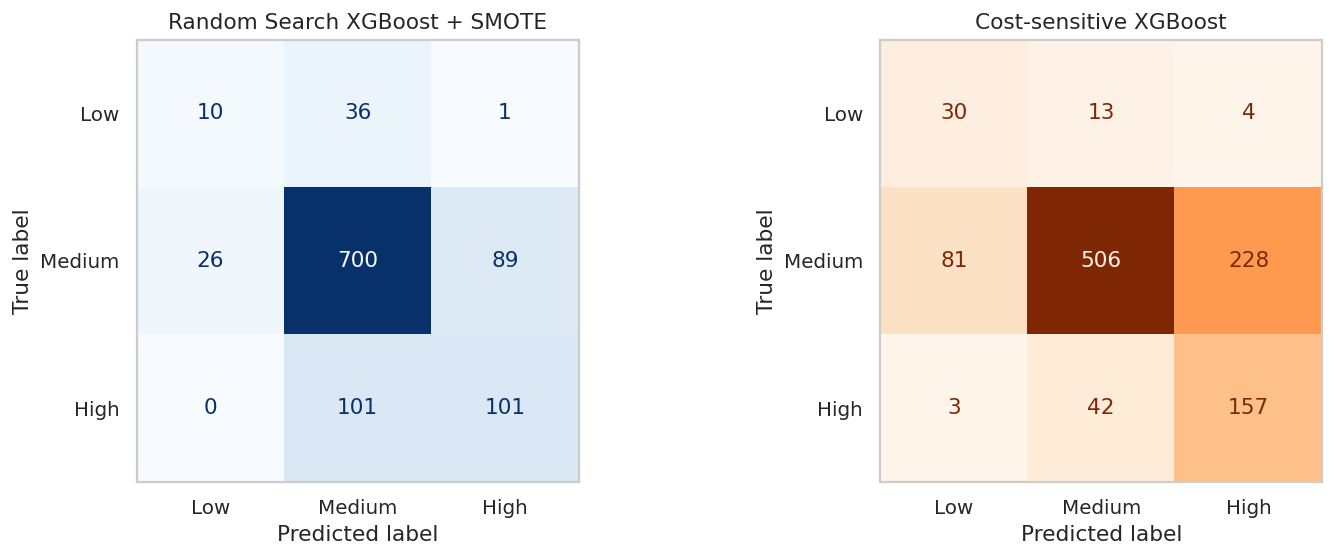

In [13]:
print("RANDOM SEARCH XGBOOST + SMOTE")
print(classification_report(
    y_test,
    y_pred_test_xgb_random,
    labels=[0, 1, 2],
    target_names=CLASS_NAMES,
    zero_division=0,
))

print("COST-SENSITIVE XGBOOST")
print(classification_report(
    y_test,
    y_pred_xgb_cost,
    labels=[0, 1, 2],
    target_names=CLASS_NAMES,
    zero_division=0,
))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test_xgb_random,
    labels=[0, 1, 2],
    display_labels=CLASS_NAMES,
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Random Search XGBoost + SMOTE")
axes[0].grid(False)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb_cost,
    labels=[0, 1, 2],
    display_labels=CLASS_NAMES,
    cmap="Oranges",
    colorbar=False,
    ax=axes[1],
)
axes[1].set_title("Cost-sensitive XGBoost")
axes[1].grid(False)

plt.tight_layout()
plt.show()

## 7. Regression experiment

Classification ignores that quality is ordered. Regression predicts the original score from 3 to 9.

We use the best XGBoost regression settings found in the detailed notebook.

In [14]:
y_quality_train = df.loc[X_train.index, "quality"]
y_quality_test = df.loc[X_test.index, "quality"]

xgb_reg = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="mae",
    n_estimators=700,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=1,
    subsample=0.70,
    colsample_bytree=0.85,
    gamma=0.0,
    reg_lambda=1,
    random_state=SEED,
    n_jobs=1,
)

xgb_reg.fit(X_train, y_quality_train)
y_pred_quality_train = xgb_reg.predict(X_train)
y_pred_quality = xgb_reg.predict(X_test)

regression_train_mae = mean_absolute_error(y_quality_train, y_pred_quality_train)
regression_mae = mean_absolute_error(y_quality_test, y_pred_quality)
regression_rmse = np.sqrt(mean_squared_error(y_quality_test, y_pred_quality))
regression_r2 = r2_score(y_quality_test, y_pred_quality)

print("REGRESSION MODEL — XGBOOST REGRESSOR")
print(f"MAE (Train): {regression_train_mae:.3f}")
print(f"MAE (Test):  {regression_mae:.3f}")
print(f"RMSE (Test): {regression_rmse:.3f}")
print(f"R² (Test):   {regression_r2:.3f}")

# Convert the predicted numerical score back into the same three classes.
# 4.5 separates scores 4 and 5. 6.5 separates scores 6 and 7.
y_pred_regression_classes_train = np.select(
    [y_pred_quality_train < 4.5, y_pred_quality_train < 6.5],
    [0, 1],
    default=2,
).astype(int)

y_pred_regression_classes = np.select(
    [y_pred_quality < 4.5, y_pred_quality < 6.5],
    [0, 1],
    default=2,
).astype(int)

regression_low_recall = recall_score(
    y_test, y_pred_regression_classes, labels=[0], average="macro", zero_division=0
)
regression_high_recall = recall_score(
    y_test, y_pred_regression_classes, labels=[2], average="macro", zero_division=0
)

print(f"Low recall after conversion:  {regression_low_recall:.2%}")
print(f"High recall after conversion: {regression_high_recall:.2%}")
print(f"Accuracy after conversion (Train): {accuracy_score(y_train, y_pred_regression_classes_train):.2%}")
print(f"Accuracy after conversion (Test):  {accuracy_score(y_test, y_pred_regression_classes):.2%}")
print(f"Balanced Accuracy (Test): {balanced_accuracy_score(y_test, y_pred_regression_classes):.2%}")
print(f"Macro F1 (Test): {f1_score(y_test, y_pred_regression_classes, average='macro'):.3f}")
print()
print("Classification Report after conversion (Test):")
print(classification_report(
    y_test,
    y_pred_regression_classes,
    labels=[0, 1, 2],
    target_names=CLASS_NAMES,
    zero_division=0,
))

REGRESSION MODEL — XGBOOST REGRESSOR
MAE (Train): 0.247
MAE (Test):  0.545
RMSE (Test): 0.707
R² (Test):   0.355
Low recall after conversion:  8.51%
High recall after conversion: 37.62%
Accuracy after conversion (Train): 95.32%
Accuracy after conversion (Test):  77.91%
Balanced Accuracy (Test): 46.01%
Macro F1 (Test): 0.482

Classification Report after conversion (Test):
              precision    recall  f1-score   support

         Low       0.22      0.09      0.12        47
      Medium       0.82      0.92      0.86       815
        High       0.59      0.38      0.46       202

    accuracy                           0.78      1064
   macro avg       0.54      0.46      0.48      1064
weighted avg       0.75      0.78      0.76      1064



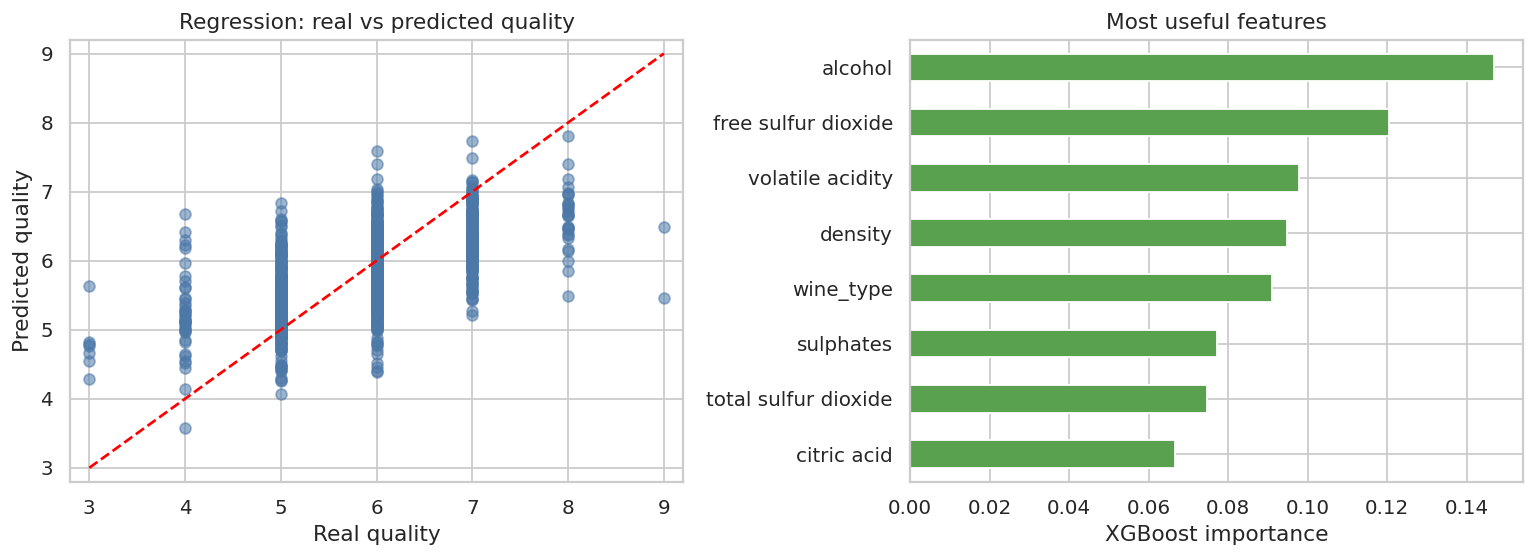

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(y_quality_test, y_pred_quality, alpha=0.55, color="#4C78A8")
axes[0].plot([3, 9], [3, 9], linestyle="--", color="red")
axes[0].set_title("Regression: real vs predicted quality")
axes[0].set_xlabel("Real quality")
axes[0].set_ylabel("Predicted quality")
axes[0].set_xlim(2.8, 9.2)
axes[0].set_ylim(2.8, 9.2)

importance = pd.Series(
    xgb_cost.feature_importances_,
    index=X.columns,
).sort_values().tail(8)
importance.plot(kind="barh", ax=axes[1], color="#59A14F")
axes[1].set_title("Most useful features")
axes[1].set_xlabel("XGBoost importance")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 8. Predict the quality of one new wine

This section can be used as a live demonstration. Enter the 11 chemical measurements, run the cell, and the best overall model returns:

- **Bad:** predicted quality 3–4
- **Normal:** predicted quality 5–6
- **Good:** predicted quality 7–8

The code automatically chooses the model with the highest test macro F1 from the comparison table.

Choose `"Red"` or `"White"`, then change the chemical measurements. Do not add `quality` because that is the value we are trying to predict.

NEW WINE INPUT
Wine type: Red
Predicted class: 1
Predicted label: Normal
Model confidence: 60.95%
Model used: Cost-sensitive XGBoost


,Value
fixed acidity,7.4000
volatile acidity,0.7000
citric acid,0.0000
residual sugar,1.9000
chlorides,0.0760
free sulfur dioxide,11.0000
total sulfur dioxide,34.0000
density,0.9978
pH,3.5100
sulphates,0.5600


,Probability
Label,
Bad,0.352
Normal,0.610
Good,0.038


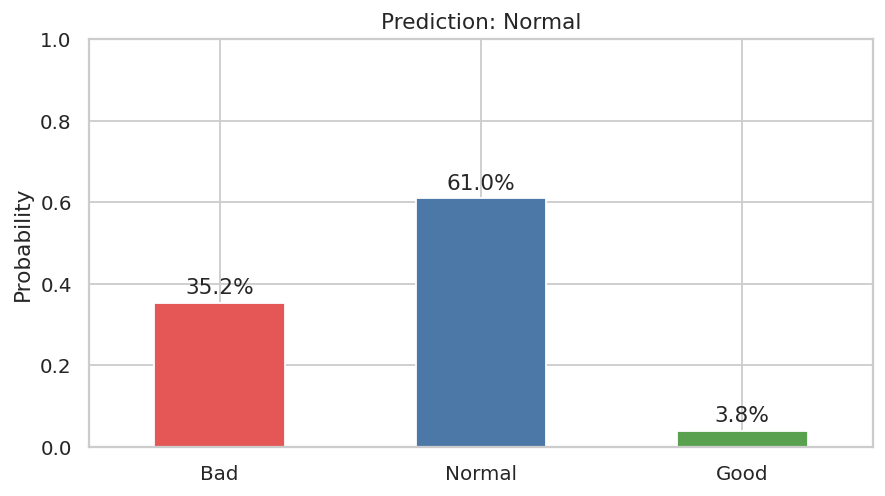

In [16]:
# Choose the wine type and enter its measurements here.
new_wine_type = "Red"  # Write "Red" or "White"

wine_type_code = {
    "Red": 0,
    "White": 1,
}[new_wine_type]

new_wine = pd.DataFrame({
    "fixed acidity": [7.4],
    "volatile acidity": [0.70],
    "citric acid": [0.00],
    "residual sugar": [1.9],
    "chlorides": [0.076],
    "free sulfur dioxide": [11.0],
    "total sulfur dioxide": [34.0],
    "density": [0.9978],
    "pH": [3.51],
    "sulphates": [0.56],
    "alcohol": [9.4],
    "wine_type": [wine_type_code],
})

# Keep the columns in exactly the same order used during training.
new_wine = new_wine[X.columns]

print("NEW WINE INPUT")
print(f"Wine type: {new_wine_type}")
display(new_wine.T.rename(columns={0: "Value"}))

classification_model_objects = {
    "Basic RF": rf_basic,
    "Weighted RF": rf_weighted,
    "Random Search XGB + SMOTE": xgb_random_best,
    "Grid Search XGB + SMOTE": xgb_smote,
    "Cost-sensitive XGBoost": xgb_cost,
}

best_prediction_model_name = classification_results["Macro F1"].idxmax()
best_prediction_model = classification_model_objects[best_prediction_model_name]

predicted_class = int(best_prediction_model.predict(new_wine)[0])
prediction_probabilities = best_prediction_model.predict_proba(new_wine)[0]

wine_labels = {
    0: "Bad",
    1: "Normal",
    2: "Good",
}

predicted_label = wine_labels[predicted_class]
confidence = prediction_probabilities[predicted_class]

print(f"Predicted class: {predicted_class}")
print(f"Predicted label: {predicted_label}")
print(f"Model confidence: {confidence:.2%}")
print(f"Model used: {best_prediction_model_name}")

probability_table = pd.DataFrame({
    "Label": ["Bad", "Normal", "Good"],
    "Probability": prediction_probabilities,
})
display(probability_table.set_index("Label").round(3))

colors = ["#E45756", "#4C78A8", "#59A14F"]
ax = probability_table.plot(
    x="Label",
    y="Probability",
    kind="bar",
    color=colors,
    legend=False,
    figsize=(7, 4),
)
ax.set_title(f"Prediction: {predicted_label}")
ax.set_ylabel("Probability")
ax.set_xlabel("")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
for container in ax.containers:
    ax.bar_label(container, labels=[f"{value:.1%}" for value in prediction_probabilities], padding=3)
plt.tight_layout()
plt.show()

# Final conclusion

## What worked

- Combining red and white wines gives 6,497 raw rows. After removing exact duplicates, 5,320 rows remain for modelling.
- `wine_type` appears among the most useful features, showing that separating red and white wine matters.
- Random and Grid Search XGBoost with SMOTE raise Low recall from about 2% to 21–23%.
- Cost-sensitive XGBoost produces the best Macro F1 (**0.546**) and finds **64% of Low wines** and **78% of High wines**.
- The best model has similar Macro F1 for red (**0.540**) and white (**0.549**) test wines.

## Main limitation

- Low wines remain only about 4% of the combined dataset.
- Basic and weighted Random Forest reach 100% training accuracy but only about 80% test accuracy. This is overfitting, and both find only about 2% of Low wines.
- The cost-sensitive model improves rare-class recall but reduces overall test accuracy to 65% because it produces more false alarms.
- Quality is partly subjective because the target comes from sensory evaluations, while our inputs contain only chemical measurements.
- The dataset has no information about price, brand, grape variety, consumer preference, or tasting conditions.
- Regression has a test MAE of **0.545 quality points** and R² of **0.355**. It is useful, but it cannot predict every tasting score precisely.

## Interpretation

Most observations are average wines. One possible business interpretation is that medium-quality wines may be the safest and most consistent product for producers. However, this is only a hypothesis: the dataset does not contain production-strategy or consumer-demand variables that can prove it.

## Final model choice

- Choose **cost-sensitive XGBoost** when all three classes matter. It has the best Macro F1, Balanced Accuracy, Low recall, and High recall in this run.
- Choose a Random Forest only when overall accuracy is more important than finding rare Low and High wines.
- Use **regression** when predicting the original numerical score is the real objective.

In [17]:
best_balanced_model = classification_results["Macro F1"].idxmax()
best_low_recall_model = classification_results["Low recall"].idxmax()

print("PROJECT TAKEAWAYS")
print("-" * 70)
print(f"Best overall class balance: {best_balanced_model}")
print(f"Best model for finding Low wines: {best_low_recall_model}")
print(f"Cost-sensitive Low recall: {classification_results.loc['Cost-sensitive XGBoost', 'Low recall']:.2%}")
print(f"Cost-sensitive High recall: {classification_results.loc['Cost-sensitive XGBoost', 'High recall']:.2%}")
print(f"Regression average error: {regression_mae:.3f} quality points")
print()
print("The main limitation is still the shortage of real Low-quality wines.")
print("Quality is also partly subjective and cannot be explained by chemistry alone.")

PROJECT TAKEAWAYS
----------------------------------------------------------------------
Best overall class balance: Cost-sensitive XGBoost
Best model for finding Low wines: Cost-sensitive XGBoost
Cost-sensitive Low recall: 63.83%
Cost-sensitive High recall: 77.72%
Regression average error: 0.545 quality points

The main limitation is still the shortage of real Low-quality wines.
Quality is also partly subjective and cannot be explained by chemistry alone.
